# Convolutional Neural Networks

# Importar Librerías

In [1]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
import keras
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import (
 #   BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
#)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [3]:
dirname = os.path.join(os.getcwd(),'C:/Users/jo296/Documents/IA/Proyecto2/dataset2')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []
prevRoot=''
cant=0

print("leyendo imagenes de ",imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant=cant+1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            if len(image.shape)==3:
                images.append(image)
                b = "Leyendo..." + str(cant)
            #print (b, end="\r")
            if prevRoot !=root:
                #print(root, cant)
                prevRoot=root
                directories.append(root)
                dircount.append(cant)
                cant=0
dircount.append(cant)

dircount = dircount[1:]
dircount[0]=dircount[0]+1
print('Directorios leidos:',len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:',sum(dircount))

leyendo imagenes de  C:/Users/jo296/Documents/IA/Proyecto2/dataset2\
Directorios leidos: 5
Imagenes en cada directorio [20229, 20000, 20002, 20346, 20341]
suma Total de imagenes en subdirs: 100918


# Creamos las etiquetas

In [4]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  100918


In [5]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 aranas
1 ballenas
2 changos
3 pajaros
4 ranas


In [6]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (100918,) + inhomogeneous part.

# Creamos Sets de Entrenamiento y Test

In [ ]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

ValueError: Found input variables with inconsistent numbers of samples: [92342, 0]

Text(0.5, 1.0, 'Ground Truth : 0')

Text(0.5, 1.0, 'Ground Truth : 0')

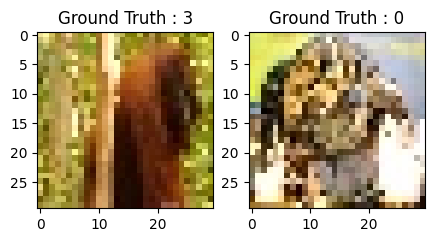

In [ ]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

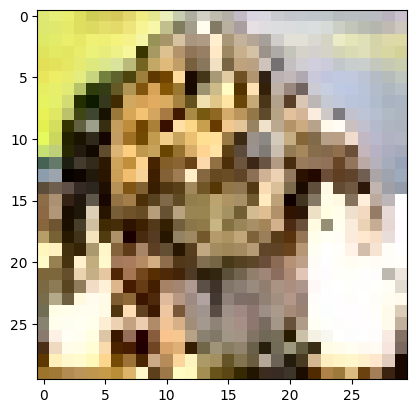

In [ ]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [ ]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 3
After conversion to one-hot: [0. 0. 0. 1. 0.]


# Creamos el Set de Entrenamiento y Validación

In [ ]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=48)

In [ ]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(37388, 30, 30, 3) (9348, 30, 30, 3) (37388, 5) (9348, 5)


# Creamos el modelo de CNN

## Estrategias de Mejora Aplicadas:
1. **Data Augmentation**: Rotaciones, desplazamientos, zoom, flips
2. **Arquitectura Mejorada**: Más capas convolucionales (64→128→256 filtros), Batch Normalization
3. **Mejores Hiperparámetros**: Learning rate 1e-4, 50 épocas, batch size 32
4. **Class Weights**: Ponderación para manejar clases desbalanceadas (especialmente Class 3)
5. **Callbacks**: Early Stopping + ReduceLROnPlateau para evitar overfitting
6. **Optimizer**: Adam en lugar de SGD (más eficiente)

# Análisis de Balance de Clases y Mejoras

In [ ]:
# Verificar balance de clases
from collections import Counter
import pandas as pd

class_counts = Counter(train_Y)
class_dist = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
class_dist['class_name'] = [deportes[i] for i in class_dist.index]
print("Balance de clases en entrenamiento:")
print(class_dist)
print("\nProporción de clases:")
print(class_dist['count'] / class_dist['count'].sum())

Balance de clases en entrenamiento:
   count class_name
3   8267    monkeys
1  11274      birds
4   9586    spiders
2   8418     whales
0   9191      ranas

Proporción de clases:
3    0.176887
1    0.241227
4    0.205110
2    0.180118
0    0.196658
Name: count, dtype: float64


In [ ]:
# Data Augmentation para mejorar la generalización
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Crear generador de datos aumentados (rotaciones, shifts, zoom, flips)
train_datagen = ImageDataGenerator(
    rotation_range=15,           # rotaciones hasta 15 grados
    width_shift_range=0.1,       # desplazamiento horizontal 10%
    height_shift_range=0.1,      # desplazamiento vertical 10%
    zoom_range=0.1,              # zoom 10%
    horizontal_flip=True,        # voltear horizontalmente
    fill_mode='nearest'
)

# No aplicar augmentation a validación
val_datagen = ImageDataGenerator()

# Modelo CNN Mejorado con Mejor Arquitectura

In [ ]:
from tensorflow.keras.layers import BatchNormalization

# Modelo mejorado con más capas y mejor regularización
sport_model = Sequential()

# Primera capa convolucional
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same', input_shape=(30,30,3)))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# Segunda capa convolucional
sport_model.add(Conv2D(128, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Conv2D(128, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# Tercera capa convolucional
sport_model.add(Conv2D(256, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.4))

# Capas densas
sport_model.add(Flatten())
sport_model.add(Dense(256, activation='linear'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(128, activation='linear'))
sport_model.add(BatchNormalization())
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

/home/edgar/Descargas/imagesDetector/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777612837.380874  534789 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/edgar/Descargas/imagesDetector/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-4  # Learning rate más bajo para mejor convergencia
epochs = 30     # Más épocas para mejor entrenamiento
batch_size = 32 # Batch size más pequeño para mejor generalización

In [ ]:
# Modelo original (comentado porque usamos el modelo mejorado arriba)
# Descomenta estas líneas si quieres usar el modelo simple
# sport_model = Sequential()
# sport_model.add(Conv2D(32, kernel_size=(3, 3),activation='linear', padding='same', input_shape=(30,30,3)))
# ...
# El modelo mejorado ya está definido arriba en la sección "Modelo CNN Mejorado"

In [ ]:
sport_model.summary()

Model: "sequential"

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,641,797 (6.26 MB)

 Trainable params: 1,639,749 (6.26 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
# Compilar con Adam optimizer (mejor que SGD) y ajuste de clase desequilibrada
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos de clases para manejar desbalance
class_weights = compute_class_weight('balanced', classes=np.unique(train_Y), y=train_Y)
class_weight_dict = dict(enumerate(class_weights))

sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)

# Entrenamos el modelo: Aprende a clasificar imágenes

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping para evitar overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Reducir learning rate si la validación no mejora
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)

# este paso puede tomar varios minutos, dependiendo de tu ordenador, cpu y memoria ram libre
# Entrenamiento con data augmentation y class weights
sport_train = sport_model.fit(
    train_datagen.flow(train_X, train_label, batch_size=batch_size),
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label),
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    steps_per_epoch=len(train_X)//batch_size
)

Epoch 1/50


Epoch 1/50


I0000 00:00:1777612838.524343  534789 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


Epoch 1/50


I0000 00:00:1777612838.524343  534789 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


...

Epoch 1/50


I0000 00:00:1777612838.524343  534789 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


1168/1168 ━━━━━━━━━━━━━━━━━━━━ 559s 473ms/step - accuracy: 0.6186 - loss: 0.9686 - val_accuracy: 0.7700 - val_loss: 0.5969 - learning_rate: 1.0000e-04
Epoch 2/50
   1/1168 ━━━━━━━━━━━━━━━━━━━━ 8:18 427ms/step - accuracy: 0.6250 - loss: 0.8360

/home/edgar/Descargas/imagesDetector/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1168/1168 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.6250 - loss: 0.8360 - val_accuracy: 0.7689 - val_loss: 0.5926 - learning_rate: 1.0000e-04
Epoch 3/50
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 543s 465ms/step - accuracy: 0.7542 - loss: 0.6397 - val_accuracy: 0.8099 - val_loss: 0.5025 - learning_rate: 1.0000e-04
Epoch 4/50
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.7500 - loss: 0.6468 - val_accuracy: 0.8110 - val_loss: 0.4998 - learning_rate: 1.0000e-04
Epoch 5/50
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 518s 443ms/step - accuracy: 0.8024 - loss: 0.5297 - val_accuracy: 0.8255 - val_loss: 0.4889 - learning_rate: 1.0000e-04
Epoch 6/50
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.8750 - loss: 0.3070 - val_accuracy: 0.8238 - val_loss: 0.4983 - learning_rate: 1.0000e-04
Epoch 7/50
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 520s 445ms/step - accuracy: 0.8295 - loss: 0.4621 - val_accuracy: 0.8381 - val_loss: 0.4474 - learning_rate: 1.0000e-04
Epoch 8/50
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 24s

In [ ]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("/home/edgar/Proyectos/IA/animal-dataset/animal_model.h5")

# Evaluamos la red

In [ ]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

W0000 00:00:1777621256.946423  534789 cpu_allocator_impl.cc:82] Allocation of 126198000 exceeds 10% of free system memory.


366/366 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.8793 - loss: 0.3104


In [ ]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.3104199469089508
Test accuracy: 0.8793324828147888


In [ ]:
sport_train.history

{'accuracy': [0.6186155080795288,
  0.625,
  0.7542295455932617,
  0.75,
  0.8023610711097717,
  0.875,
  0.8294785022735596,
  0.75,
  0.8501713275909424,
  0.71875,
  0.8672770261764526,
  0.90625,
  0.8791090846061707,
  0.9375,
  0.8891744017601013,
  0.90625,
  0.8987311124801636,
  0.875,
  0.9062533378601074,
  0.9375,
  0.9186743497848511,
  0.96875,
  0.9232251644134521,
  0.875],
 'loss': [0.9686486721038818,
  0.8360226154327393,
  0.6397340893745422,
  0.646763801574707,
  0.5297211408615112,
  0.3070499300956726,
  0.46211928129196167,
  0.5422763824462891,
  0.4115113615989685,
  0.5027556419372559,
  0.3704315423965454,
  0.35699793696403503,
  0.33633485436439514,
  0.3378881514072418,
  0.3107435703277588,
  0.2629335820674896,
  0.28354793787002563,
  0.31117916107177734,
  0.2665010094642639,
  0.22196318209171295,
  0.23164406418800354,
  0.13030216097831726,
  0.21749231219291687,
  0.37943801283836365],
 'val_accuracy': [0.7700042724609375,
  0.7689345479011536,
 

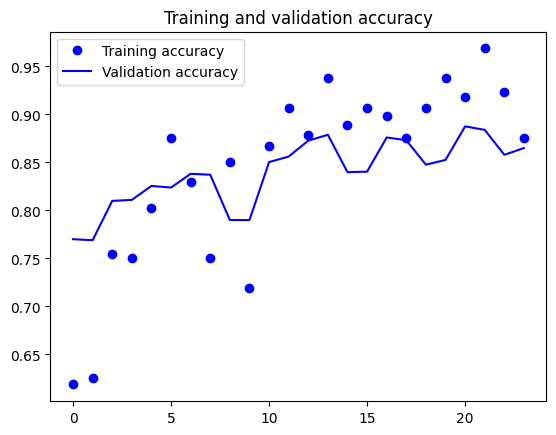

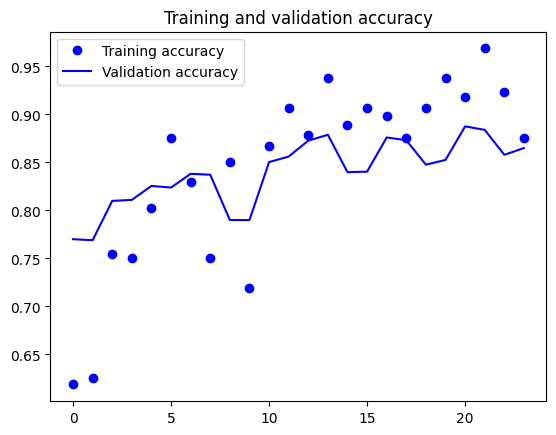

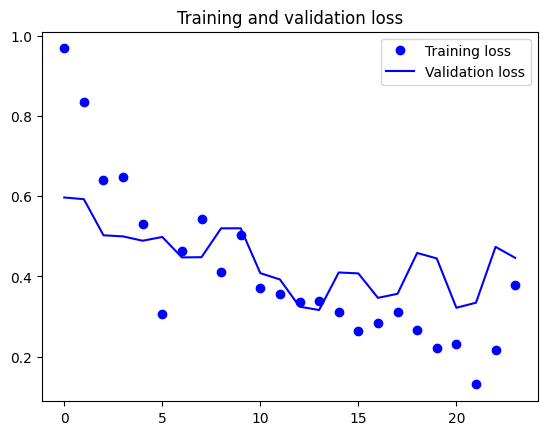

In [ ]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
predicted_classes2 = sport_model.predict(test_X)

W0000 00:00:1777621301.631546  534789 cpu_allocator_impl.cc:82] Allocation of 126198000 exceeds 10% of free system memory.


W0000 00:00:1777621301.631546  534789 cpu_allocator_impl.cc:82] Allocation of 126198000 exceeds 10% of free system memory.


366/366 ━━━━━━━━━━━━━━━━━━━━ 43s 115ms/step


In [ ]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [ ]:
predicted_classes.shape, test_Y.shape

((11685,), (11685,))

# Aprendamos de los errores: Qué mejorar

Found 10275 correct labels


Found 10275 correct labels


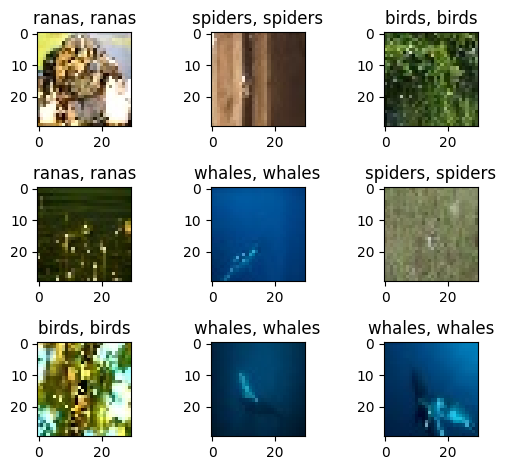

In [ ]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(28,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 1410 incorrect labels


Found 1410 incorrect labels


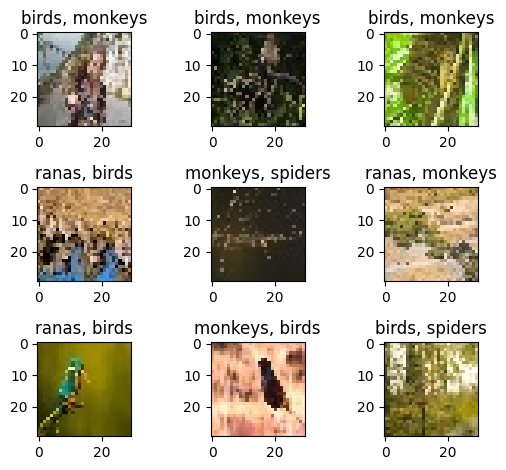

In [ ]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(28,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [ ]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.89      0.86      0.87      2335
     Class 1       0.78      0.91      0.84      2911
     Class 2       1.00      1.00      1.00      2068
     Class 3       0.82      0.72      0.77      2071
     Class 4       0.96      0.90      0.93      2300

    accuracy                           0.88     11685
   macro avg       0.89      0.88      0.88     11685
weighted avg       0.88      0.88      0.88     11685



In [ ]:
from tensorflow.keras.models import load_model
from skimage.transform import resize

# Cargar el modelo guardado
sport_model = load_model("C:/Users/jo296/Documents/IA/Proyecto2/animal_model.h5")

images=[]
# AQUI ESPECIFICAMOS UNAS IMAGENES
filenames = [
    'C:/Users/jo296/Documents/IA/Proyecto2/dataset2/aranas/imagen_arana_0.jpg',
    'C:/Users/jo296/Documents/IA/Proyecto2/dataset2/ballenas/ballena_00000.jpg',
    'C:/Users/jo296/Documents/IA/Proyecto2/dataset2/changos/changos_1_01045.jpg',
    'C:/Users/jo296/Documents/IA/Proyecto2/dataset2/pajaros/pajaros_00000.jpg',
    'C:/Users/jo296/Documents/IA/Proyecto2/dataset2/ranas/ranas_1.jpg'
            ]

for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = resize(image, (28, 28),anti_aliasing=True,clip=False,preserve_range=True)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = sport_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], deportes[img_tagged.tolist().index(max(img_tagged))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
/home/edgar/Descargas/mono-test.jpeg monkeys
/home/edgar/Descargas/ballena-test.jpeg whales
/home/edgar/Descargas/rana-test.jpeg birds
/home/edgar/Descargas/pajaro-test2.jpg ranas


In [ ]:
# Recomendaciones Adicionales para Mejoras Futuras:

## Si aún necesitas más precisión (90%+):
1. **Transfer Learning**: Usar MobileNetV2 o EfficientNet preentrenados
2. **Aumentar imagen**: De 30x30 a 64x64 o 128x128
3. **Más datos de entrenamiento**: Especialmente para Class 3 (que tiene bajo recall)
4. **Ensemble**: Combinar múltiples modelos
5. **Augmentation avanzada**: Mixup, Cutmix
6. **Hiperparámetros**: Usar GridSearch o RandomSearch para optimizar

## Para debugging:
- Revisa qué imágenes se clasifican mal (Class 3)
- Considera si las categorías se solapan o son ambiguas
- Aumenta específicamente los datos del Class 3


SyntaxError: invalid decimal literal (2442598661.py, line 5)